#### Exercise 1 - Starter - Correlation v Causation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf


In [2]:

# Set random seed for reproducibility
np.random.seed(42)

# Number of users
n_users = 2000

# 1. Affinity score (1 to 100): How much does the customer inherently like the product or platform?
affinity = np.random.uniform(1, 100, size=n_users)

# Original sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-0.1 * (x - 50)))

loyalty_signup_probability = sigmoid(affinity)

# 3. Sign-up assignment (1 = signed up, 0 = did not)
loyalty_signup = np.random.binomial(1, loyalty_signup_probability)


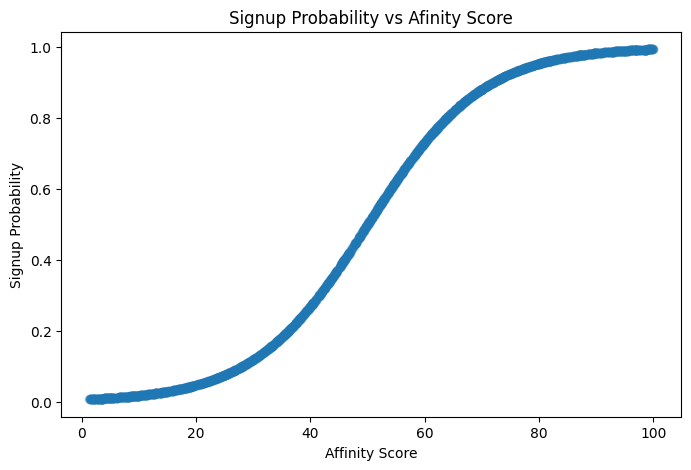

/tmp/ipykernel_13/4191036788.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate_by_bin = df.groupby("affinity_bin")["signup"].mean()
/tmp/ipykernel_13/4191036788.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_centers = df.groupby("affinity_bin")["affinity"].mean()


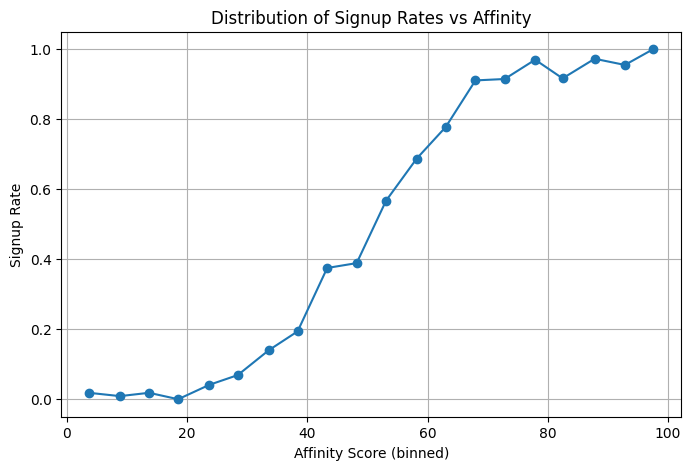

In [13]:

# TO-DO: plot signup rate probability against affinity scores  
plt.figure(figsize=(8,5))

plt.scatter(affinity, loyalty_signup_probability, alpha=0.3)
# plt.plot(np.linspace(1,100, 500), sigmoid(np.linspace(1,100, 500)), linewidth=2)
plt.xlabel('Affinity Score')
plt.ylabel('Signup Probability')
plt.title('Signup Probability vs Afinity Score')
plt.show()

# TO-DO: Plot the distribution of signup rates against affinity scores 

df = pd.DataFrame({
    "affinity": affinity,
    "signup": loyalty_signup
})

df["affinity_bin"] = pd.cut(df["affinity"], bins=20)

# --- compute signup rate per bin ---
rate_by_bin = df.groupby("affinity_bin")["signup"].mean()
bin_centers = df.groupby("affinity_bin")["affinity"].mean()


plt.figure(figsize=(8,5))
plt.plot(bin_centers, rate_by_bin, marker="o")
plt.xlabel("Affinity Score (binned)")
plt.ylabel("Signup Rate")
plt.title("Distribution of Signup Rates vs Affinity")
plt.grid(True)
plt.show()


In [16]:

# Generate Customer Revenue as linear function of affinity and signup status 
# Base revenue + boost for affinity + any boost for status + random noise

impact_affinity = 2 # incremental revenue per affinity point 
impact_loyalty_signup = 0 # no additional revenue boost for loyalty signup in this case
monthly_revenue = 20 + impact_affinity * affinity + impact_loyalty_signup * loyalty_signup + np.random.normal(0, 5, size=n_users)


# TO-DO: Build DataFrame using affinity, loyalty_signup, and monthly_revenue. View data summary using describe()
data = pd.DataFrame({
    'affinity': affinity,
    'signup': loyalty_signup,
    'monthly_revenue': monthly_revenue
})

data.describe()

,affinity,signup,monthly_revenue
count,2000.000000,2000.000000,2000.000000
mean,50.365056,0.496000,120.514137
std,28.928869,0.500109,58.208056
min,1.318608,0.000000,13.850722
25%,24.566601,0.000000,69.879732
50%,51.227776,0.000000,121.783174
75%,75.317204,1.000000,170.975032
max,99.972050,1.000000,226.243182


In [17]:
# TO-DO: Describe mean and standard deviation of revenue and affinity by loyalty signup status
data.groupby(['signup'])[['affinity', 'monthly_revenue']].agg(['mean', 'std'])

affinity            monthly_revenue           
             mean        std            mean        std
signup                                                 
0       28.229194  18.935288       76.133118  38.057140
1       72.857948  17.858846      165.610978  36.380038

In [27]:
# TO-DO: Calculate and print the revenue gap (difference in average revenue) by signup status 
gap = data.groupby('signup')['monthly_revenue'].mean().diff().iloc[1]
print(gap)
# TO-DO: t-test for the difference in monthly revenue using scipy.stats.ttest_ind 

a=data[data['signup']==0]['monthly_revenue']
b=data[data['signup']==1]['monthly_revenue']
result = stats.ttest_ind(a, b, alternative='two-sided',equal_var=False)
print(result.pvalue)

89.47785989598778
0.0


In [24]:
# TO-DO: Estimate linear Regression of revenue on affinity and loyalty status using statsmodels.formula.api.ols 

formula = 'monthly_revenue~affinity+C(signup)'
model = smf.ols(formula = formula , data=data).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        monthly_revenue   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                 1.281e+05
Date:                Thu, 27 Nov 2025   Prob (F-statistic):               0.00
Time:                        10:55:50   Log-Likelihood:                -6103.7
No. Observations:                2000   AIC:                         1.221e+04
Df Residuals:                    1997   BIC:                         1.223e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         19.5791      0.239     82.

In [26]:
# But we don't observe affinity directly, we only observe signup status.
# TO-DO Regression of revenue on signup status without affinity as a control 
formula = 'monthly_revenue~C(signup)'
model = smf.ols(formula = formula , data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        monthly_revenue   R-squared:                       0.591
Model:                            OLS   Adj. R-squared:                  0.591
Method:                 Least Squares   F-statistic:                     2887.
Date:                Thu, 27 Nov 2025   Prob (F-statistic):               0.00
Time:                        10:56:45   Log-Likelihood:                -10071.
No. Observations:                2000   AIC:                         2.015e+04
Df Residuals:                    1998   BIC:                         2.016e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         76.1331      1.173     64.